# Autoencoder Training

This notebook trains a convolutional autoencoder on **normal data** (no chatter).  
The model learns a compact representation and attempts to reconstruct the input images.  
Because anomalous samples (chatter) are not seen during training, we expect them to yield a **higher reconstruction error**.

**Core idea:** anomaly score = reconstruction error (e.g., MSE) between the input and its reconstruction.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from PIL import Image
from tqdm import tqdm
import plotly.express as px 
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Dense, Flatten, Reshape
import matplotlib.pyplot as plt

In [2]:
# =========================
# Reproducibility (Seeds)
# =========================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# GPU check (optional)
# =========================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"TensorFlow detects {len(gpus)} GPU(s):")
    for gpu in gpus:
        print("-", gpu)
else:
    print("No GPU found.")

No GPU found.


## Data

The spectrograms are loaded as images.

We distinguish between:
- **GOOD / Normal**: samples without chatter (used for training)
- **BAD / Chatter**: potentially anomalous samples (typically used for evaluation)

This notebook trains the autoencoder using **only the normal (GOOD)** class.

In [3]:
DATA_GOOD = "../data/02_spectrograms_150x100px/no_chatter"
DATA_BAD = "../data/02_spectrograms_150x100px/chatter"

In [4]:
def load_images_from_folder(folder, target_size=(150, 100)):
    """
    Load all images from a folder, resize them to target_size,
    convert to RGB, and return a NumPy array of shape (N, H, W, C).
    """
    images = []
    valid_ext = ('.png', '.jpg', '.jpeg')

    for file in tqdm(os.listdir(folder)):
        if file.lower().endswith(valid_ext):
            path = os.path.join(folder, file)
            img = Image.open(path).convert("RGB").resize(target_size)
            images.append(np.array(img))

    return np.array(images)

Load only normal data!

In [5]:
images = load_images_from_folder(DATA_GOOD)

# Normalize to [0, 1]
images = images.astype("float32") / 255.0
print("Loaded normal samples:", images.shape)

# Split into training and validation sets (only normal data)
x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train:", x_train.shape)
print("Val:", x_val.shape)

100%|██████████| 291/291 [00:16<00:00, 17.14it/s]


Loaded normal samples: (291, 100, 150, 3)
Train: (232, 100, 150, 3)
Val: (59, 100, 150, 3)


## Visualization / Sanity Check

To verify the data pipeline, we visualize one example spectrogram from the training set.
This helps confirm that resizing and normalization behave as expected.

In [6]:
fig = px.imshow(x_train[10])
fig.update_layout(coloraxis_showscale=False)
fig.show()

## Model: Convolutional Autoencoder

The autoencoder consists of three parts: 

1. **Encoder**: extracts features using convolutions and progressively reduces spatial dimensions
2. **Bottleneck**: compresses the representation using a dense layer
3. **Decoder**: reconstructs the input via dense expansion, reshaping, upsampling, and convolutions

### Training objective
The model minimizes the reconstruction error (MSE) between the input image $x$ and its reconstruction $\hat{x}$.

During anomaly detection, the reconstruction error is used as an anomaly score.

In [7]:
input_shape = (100, 150, 3)

# Sequential-Modell
autoencoder = Sequential()

# ---- Encoder ----
autoencoder.add(Conv2D(4, (3, 3), activation='relu', padding='same', input_shape=input_shape))
autoencoder.add(MaxPooling2D((2, 2), padding='same'))  

autoencoder.add(Conv2D(8, (3, 3), activation='relu', padding='same'))  
autoencoder.add(MaxPooling2D((2, 3), padding='same')) 

autoencoder.add(Conv2D(12, (3, 3), activation='relu', padding='same')) 

# ---- Bottleneck ----
autoencoder.add(Flatten()) 
autoencoder.add(Dense(16, activation='relu'))  # compact latent representation

# ---- Decoder ----
autoencoder.add(Dense(25 * 25 * 12, activation='relu'))  
autoencoder.add(Reshape((25, 25, 12)))  
autoencoder.add(Conv2D(12, (3, 3), activation='relu', padding='same')) 

autoencoder.add(UpSampling2D((2, 3)))  
autoencoder.add(Conv2D(8, (3, 3), activation='relu', padding='same')) 

autoencoder.add(UpSampling2D((2, 2))) 
autoencoder.add(Conv2D(4, (3, 3), activation='relu', padding='same'))

autoencoder.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same')) 

c:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\.spectro-ae-venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Training Setup

- **Optimizer:** Adam with a small learning rate
- **Loss:** Mean Squared Error (MSE), measuring reconstruction quality

Because the autoencoder is trained on normal data only, anomalous inputs are expected to produce larger reconstruction errors.

In [11]:
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse'
)

autoencoder.summary()

history = autoencoder.fit(
    x_train, x_train,  # Autoencoder target is the input itself
    epochs=4000,
    batch_size=32,
    validation_data=(x_val, x_val),
    shuffle=True
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 150, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 75, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 75, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 12)     │           876 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       120,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7500)           │       127,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 25, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 75, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 75, 8)      │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 150, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 150, 4)    │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 100, 150, 3)    │           111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,383 (981.96 KB)

 Trainable params: 251,383 (981.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 2/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 3/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 4/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 5/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 6/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 7/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 9/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 10/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 11/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 12/4000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0

## Reconstruction on a Sample

To qualitatively verify the training, we select a single validation sample and run the autoencoder to obtain its reconstruction.  
We then compute the reconstruction error (MSE) between the original input and the reconstructed output.


Reconstruction MSE: 0.000920


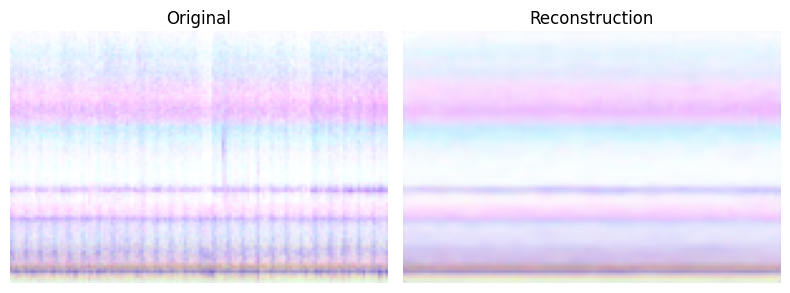

In [14]:
# -----------------------------
# Sample selection
# -----------------------------
idx = 23  # choose any index in the validation set
sample = x_val[idx]
sample_input = np.expand_dims(sample, axis=0)  # shape: (1, H, W, C)

# -----------------------------
# Reconstruction
# -----------------------------
recon = autoencoder.predict(sample_input, verbose=0)[0]

# -----------------------------
# Reconstruction Error (MSE)
# -----------------------------
mse = np.mean((sample - recon) ** 2)
print(f"Reconstruction MSE: {mse:.6f}")

# -----------------------------
# Visualization: original vs reconstruction
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(sample)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(recon)
axs[1].set_title("Reconstruction")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Saving the Trained Model

To enable reuse and reproducibility, we save the trained autoencoder to disk.  
The saved model can later be loaded for evaluation on anomalous data or for inference in other scripts.

In [13]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "ae_bn16_20260615.keras"

# -----------------------------
# Save the trained model
# -----------------------------
autoencoder.save(model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\ae_bn16_20260615.keras
